# Retrieval Score Visualization

Notebook for visualizing outputs from `op3_analysis.retrieval.cli`.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
except ImportError as exc:
    raise ImportError("This notebook requires seaborn. Install with: pip install seaborn") from exc

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [7]:
# Update this prefix to switch runs.
OUTPUT_PREFIX = "my_run_fast"

# Works if notebook is run from repo root or from notebooks/.
candidate_roots = [Path("."), Path("..")]
results_dir = None
for root in candidate_roots:
    p = (root / "results").resolve()
    if p.exists():
        results_dir = p
        break
if results_dir is None:
    raise FileNotFoundError("Could not find results directory. Expected ./results or ../results")

detail_path = results_dir / f"{OUTPUT_PREFIX}_detail.csv"
summary_cell_path = results_dir / f"{OUTPUT_PREFIX}_summary_by_cell_type.csv"
summary_overall_path = results_dir / f"{OUTPUT_PREFIX}_summary_overall.csv"

for p in [detail_path, summary_cell_path, summary_overall_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing expected output file: {p}")

detail_df = pd.read_csv(detail_path)
summary_cell_df = pd.read_csv(summary_cell_path)
summary_overall_df = pd.read_csv(summary_overall_path)

print(f"Loaded: {detail_path.name} rows={len(detail_df):,}")
print(f"Loaded: {summary_cell_path.name} rows={len(summary_cell_df):,}")
print(f"Loaded: {summary_overall_path.name} rows={len(summary_overall_df):,}")
display(summary_overall_df.head())

Loaded: my_run_fast_detail.csv rows=964
Loaded: my_run_fast_summary_by_cell_type.csv rows=12
Loaded: my_run_fast_summary_overall.csv rows=12


,query_dataset,db_dataset,representation,metric,n_queries,n_candidates_mean,n_candidates_median,rank_mean,rank_median,rank_over_n_mean,rank_normalized_mean,retrieval_score_mean,retrieval_score_median
0,sciplex,tahoe,B,spearman,107,379.0,379.0,196.467290,220.0,0.518383,0.517109,0.482891,0.420635
1,sciplex,tahoe,P.Value,spearman,107,379.0,379.0,170.429907,177.0,0.449683,0.448227,0.551773,0.534392
2,sciplex,tahoe,logFC,spearman,107,379.0,379.0,139.168224,129.0,0.367198,0.365524,0.634476,0.661376
3,sciplex,tahoe,signed_-log10(p)*sign(logFC),spearman,107,379.0,379.0,141.242991,119.0,0.372673,0.371013,0.628987,0.687831
4,sciplex,tahoe,t,spearman,107,379.0,379.0,141.280374,119.0,0.372771,0.371112,0.628888,0.687831


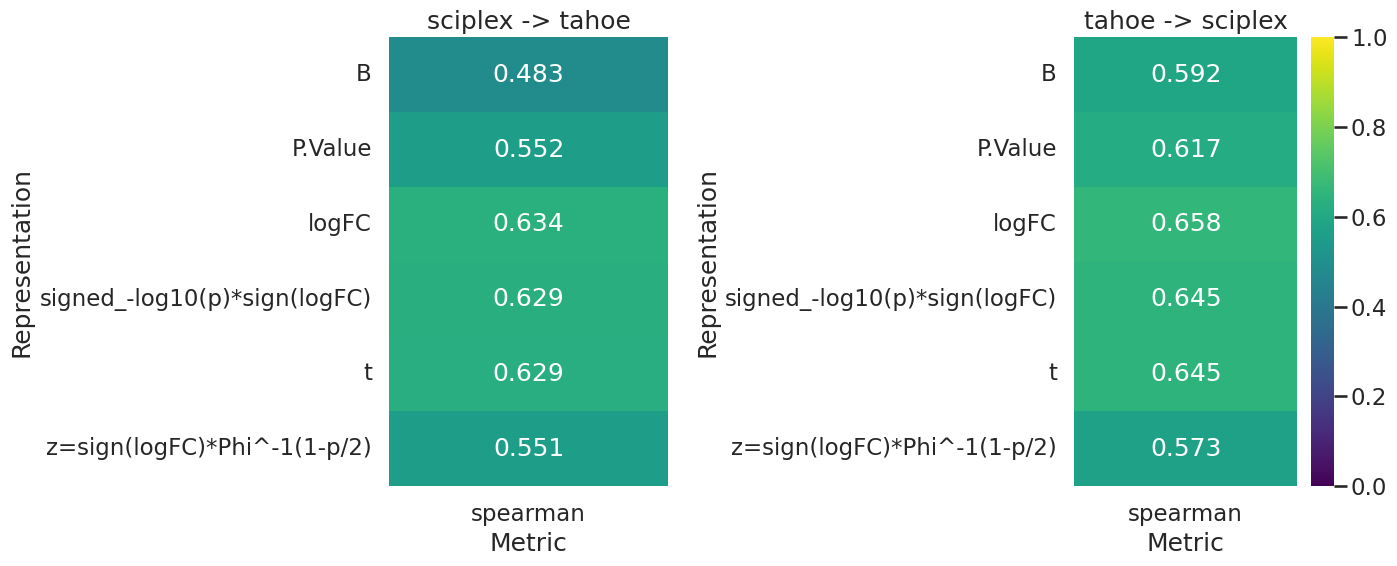

In [8]:
# Overall heatmap: retrieval_score_mean by representation and metric, faceted per dataset pair.
pairs = (
    summary_overall_df[["query_dataset", "db_dataset"]]
    .drop_duplicates()
    .sort_values(["query_dataset", "db_dataset"])
    .itertuples(index=False, name=None)
)
pairs = list(pairs)

n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 6), squeeze=False)

for i, (qds, dds) in enumerate(pairs):
    ax = axes[0, i]
    sub = summary_overall_df[
        (summary_overall_df["query_dataset"] == qds) &
        (summary_overall_df["db_dataset"] == dds)
    ]
    pivot = sub.pivot(index="representation", columns="metric", values="retrieval_score_mean")
    pivot = pivot.sort_index()
    sns.heatmap(
        pivot,
        ax=ax,
        annot=True,
        fmt=".3f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        cbar=(i == n_pairs - 1),
    )
    ax.set_title(f"{qds} -> {dds}")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Representation")

plt.tight_layout()
plt.show()

/var/tmp/ipykernel_268101/366400120.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


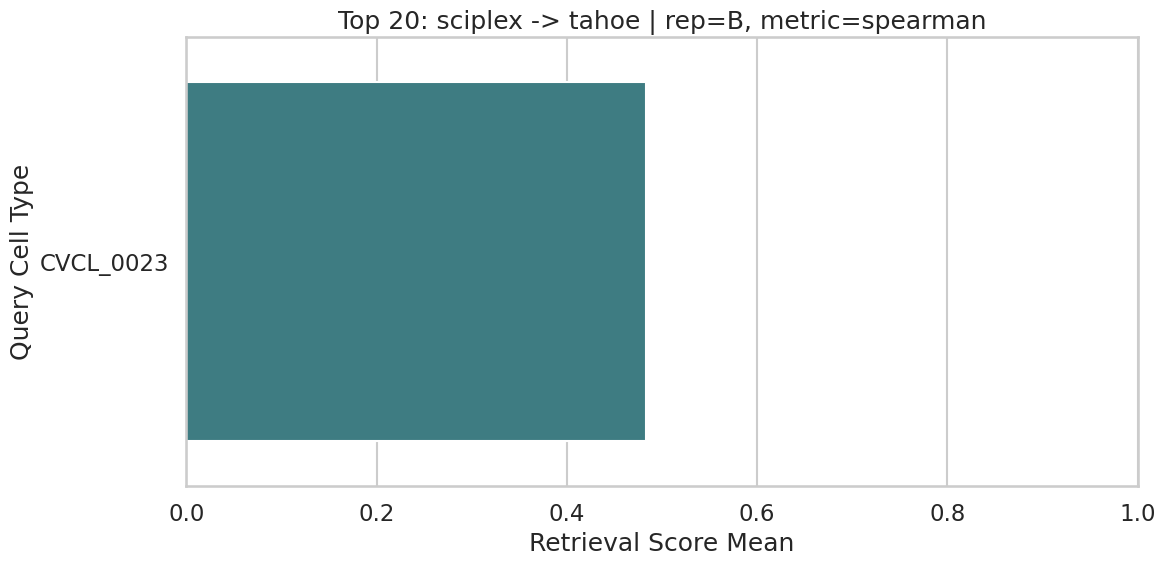

,query_cell_type,n_queries,retrieval_score_mean,retrieval_score_median
0,CVCL_0023,107,0.482891,0.420635


In [9]:
# Per-cell-type performance: top cell types by retrieval score mean for a selected setup.
SELECT_QUERY_DATASET = summary_cell_df["query_dataset"].iloc[0]
SELECT_DB_DATASET = summary_cell_df["db_dataset"].iloc[0]
SELECT_METRIC = summary_cell_df["metric"].iloc[0]
SELECT_REPRESENTATION = summary_cell_df["representation"].iloc[0]
TOP_N = 20

sub = summary_cell_df[
    (summary_cell_df["query_dataset"] == SELECT_QUERY_DATASET) &
    (summary_cell_df["db_dataset"] == SELECT_DB_DATASET) &
    (summary_cell_df["metric"] == SELECT_METRIC) &
    (summary_cell_df["representation"] == SELECT_REPRESENTATION)
].copy()

sub = sub.sort_values("retrieval_score_mean", ascending=False).head(TOP_N)

plt.figure(figsize=(12, max(6, 0.4 * len(sub))))
sns.barplot(
    data=sub,
    x="retrieval_score_mean",
    y="query_cell_type",
    palette="crest",
)
plt.xlim(0, 1)
plt.xlabel("Retrieval Score Mean")
plt.ylabel("Query Cell Type")
plt.title(
    f"Top {TOP_N}: {SELECT_QUERY_DATASET} -> {SELECT_DB_DATASET} | "
    f"rep={SELECT_REPRESENTATION}, metric={SELECT_METRIC}"
)
plt.tight_layout()
plt.show()

display(sub[["query_cell_type", "n_queries", "retrieval_score_mean", "retrieval_score_median"]].head(10))

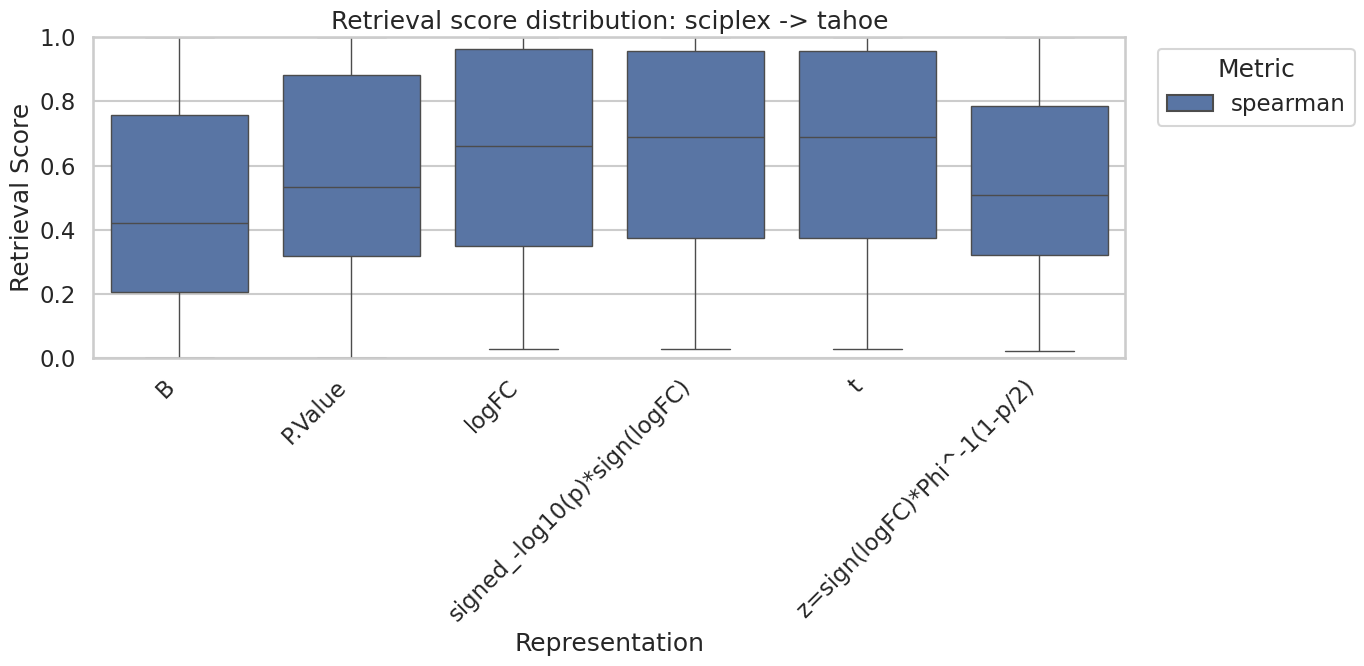

,index,representation,metric,mean,median,count
2,2,logFC,spearman,0.634476,0.661376,107
3,3,signed_-log10(p)*sign(logFC),spearman,0.628987,0.687831,107
4,4,t,spearman,0.628888,0.687831,107
1,1,P.Value,spearman,0.551773,0.534392,107
5,5,z=sign(logFC)*Phi^-1(1-p/2),spearman,0.551310,0.507143,68
0,0,B,spearman,0.482891,0.420635,107


In [10]:
# Detail-level distribution: score distribution by representation for one dataset pair.
pair = detail_df[["query_dataset", "db_dataset"]].drop_duplicates().iloc[0]
qds, dds = pair["query_dataset"], pair["db_dataset"]

sub = detail_df[
    (detail_df["query_dataset"] == qds) &
    (detail_df["db_dataset"] == dds)
].copy()

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=sub,
    x="representation",
    y="retrieval_score",
    hue="metric",
    showfliers=False,
)
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Representation")
plt.ylabel("Retrieval Score")
plt.title(f"Retrieval score distribution: {qds} -> {dds}")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

display(
    sub.groupby(["representation", "metric"], as_index=False)["retrieval_score"]
    .agg(["mean", "median", "count"]).reset_index()
    .sort_values(["mean", "median"], ascending=False)
    .head(15)
)